<a href="https://colab.research.google.com/github/markajbell/BH/blob/main/ShortestPath-8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [508]:
import pandas as pd
import json
import os
import glob

Set the Path to the Data location (imported form SharpHound)

# Set the Path
to the Data location (imported from SharpHound) and Read json files in folder and create a dictionary with the entire data.





In [711]:
#!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure.json
#!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure10k.json

#!mkdir = "/content/adsync"
#!mv secure.json /content/adsync
#!mv secure10k.json /content/adsync

path = "/content/adsync"
data = {}
json_files = glob.glob(os.path.join(path, "*.json"))
for file in json_files:
    filename = os.path.basename(file).replace(".json", "")
    suf = filename.split("_")[-1]

    with open(file, 'r', encoding='utf-8') as f:
        content = json.load(f)

    if "data" in content:
        if suf in data:
            data[f"{suf}"].extend(content["data"])
            #print(f" The key 'data' was found in {f}.")
        else:
            data[f"{suf}"] = content["data"]
            #print(f" The key 'data' was found in {f}.")
    else:
        print(f"Warning: The key 'data' was not found in {f}.")

Show the "content"

In [510]:
#content


In [713]:
# prompt: if the type column = "node" save that record into a pandas dataframe called nodes, if the type = "relationship' then save to a pandas dataframe called edges

import pandas as pd
df = pd.DataFrame(data[suf])
nodes = df[df['type'] == 'node'].copy()
edges = df[df['type'] == 'relationship'].copy()
nodes['id'] = nodes['id'].astype(int)

In [512]:
print(len(nodes))
print(len(edges))# prompt: what is the length of nodes['id] for the last record


10075
48321


In [513]:
#nodes.tail()

#print(len(nodes["id"].iloc[-1]))

In [514]:
# prompt: show all rows


pd.set_option('display.max_rows', None)



In [515]:
# prompt: for every record in "nodes" create a l1, l2 and l3 column for the values in "nodes.labels" eg. for record 1 l1=Base, l2=OU and l3 would be null

import pandas as pd
def extract_labels(labels):
    # Ensure labels is a list
    if not isinstance(labels, list):
        return [None, None, None]

    l1 = labels[0] if len(labels) > 0 else None
    l2 = labels[1] if len(labels) > 1 else None
    l3 = labels[2] if len(labels) > 2 else None
    return [l1, l2, l3]

# Apply the function to create the new columns
nodes[['l1', 'l2', 'l3']] = nodes['labels'].apply(lambda x: pd.Series(extract_labels(x)))


In [516]:
# prompt: remove the following columns from nodes:
# start, end, label

nodes = nodes.drop(columns=['start', 'end', 'label', 'labels'])


In [714]:

edges = edges.drop(columns=['labels'])


Expand "Properties" column in new columns.

Convert to Dict

In [518]:
pd.set_option("display.max_rows", None, "display.max_columns", None)

#nodes

In [715]:
#edges = edges.drop(columns=['id'])
import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')
nodes['weight'] = 1

In [520]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
pd.set_option('display.max_colwidth', None)

#nodes.tail()

In [521]:
lastnode=(len(str(nodes['id'].iloc[-1])))

new_node_id = int('9' * lastnode)

print(f"The new node ID is: {new_node_id}")

The new node ID is: 99999


In [522]:
#prompt: create a new record in nodes where id=new_node_id, properties = {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-99999', 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False}, type=node, l1=ALL_T0, l2=ALL_T0, l3=ALL_T0

# Create a dictionary with the new record's data
new_node_data = {
    'id': new_node_id,
    'properties': {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-' + str(new_node_id), 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False},
    'type': 'node',
    'l1': 'ALL_T0',
    'l2': 'ALL_T0',
    'l3': 'ALL_T0',
    'weight': int(100) # Assuming a default weight, you can adjust if needed
}
#new_node_data

# Convert the dictionary to a DataFrame
new_node_df = pd.DataFrame([new_node_data])

# Concatenate the new DataFrame with the existing nodes DataFrame
nodes = pd.concat([nodes, new_node_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Nodes DataFrame after adding the new record:")
#display(nodes.tail())

Nodes DataFrame after adding the new record:


In [644]:
#1/0
# tier0_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 0' in x.get('distinguishedname', ''))]['id'].tolist()
# tier0_node_ids

tier0_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 0', 'Tier 0', 'T0', 'TIER0']
        )
    )
]['id'].tolist()


tier1_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 1', 'Tier 1', 'T1']
        )
    )
]['id'].tolist()

tier2_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 2', 'Tier 2', 'T2']
        )
    )
]['id'].tolist()

print(f"tier 0 ",len(tier0_node_ids))
# tier1_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 1' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 1 ",len(tier1_node_ids))

# tier2_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 2' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 2 ",len(tier2_node_ids))

tier 0  518
tier 1  701
tier 2  8933


In [716]:
edg = edges[edges['label'] == 'TIER0']
edg.head()

,id,properties,type,start,end,label


In [718]:
df_trimmed = edges.iloc[:-518]
df_trimmed.tail()
tier0_node_ids

array([ 6225,  6228,  6229,  6230,  6231,  6261,  6263,  6265,  6284,
        6285,  6290,  6291,  6297,  6373,  6374,  6375,  6376,  6377,
        6378,  6381,  6387,  6389,  6390,  6401,  6406,  6409,  6412,
        6416,  6424,  6425,  6429,  6430,  6431,  6434,  6437,  6438,
        6445,  6446,  6447,  6450,  6459,  6461,  6462,  6463,  6465,
        6467,  6469,  6471,  6476,  6478,  6482,  6483,  6485,  6490,
        6497,  6502,  6503,  6509,  6510,  6511,  6512,  6515,  6520,
        6529,  6530,  6536,  6538,  6540,  6542,  6544,  6546,  6550,
        6551,  6559,  6563,  6564,  6568,  6572,  6574,  6576,  6578,
        6579,  6587,  6593,  6595,  6597,  6603,  6608,  6609,  6610,
        6612,  6615,  6616,  6628,  6633,  6635,  6640,  6643,  6651,
        6660,  6664,  6671,  6674,  6678,  6679,  6688,  6689,  6697,
        6698,  6699,  9673,  9690,  9723,  9733,  9787,  9794,  9795,
        9804,  9835,  9842,  9850,  9873,  9885,  9892,  9922,  9923,
        9924,  9928,

In [719]:
# prompt: for each value in tier0_node_ids add a new record in edges where start = value and end = new_node_id, label=TIER0,weight=100 id=id+1

# Get the maximum existing edge ID
max_edge_id = edges['id'].max()
max_edge_id
new_edges = []
for i, tier0_id in enumerate(tier0_node_ids):
    new_edge = {
        'type': 'relationship',  # Assuming type is always 'relationship' for edges
        'start': tier0_id,
        'end': new_node_id,
        'label': 'TIER0',
        'weight': 100,
        'id': max_edge_id + i + 1 # Assign a unique ID
    }
    new_edges.append(new_edge)

# Convert the list of new edges to a DataFrame
new_edges_df = pd.DataFrame(new_edges)

# Concatenate the new edges DataFrame with the existing edges DataFrame
edges = pd.concat([edges, new_edges_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Edges DataFrame after adding new TIER0 edges:")
#display(edges.tail())

Edges DataFrame after adding new TIER0 edges:


In [ ]:
#print(nodes[nodes['Tier0'] == 1])


Here


In [526]:
# prompt: find records from nodes where distinguishedname has "CN=Enterprise Admins," or  distinguishedname has "CN=Domain Admins,"  then append id to tier0_node_ids if not already present

# Assuming 'nodes' DataFrame is already defined from the preceding code

# Initialize an empty list to store the IDs
#tier0_node_ids = []

# Iterate through each row of the 'nodes' DataFrame
# for index, row in nodes.iterrows():
#     properties = row['properties']
#     node_id = row['id']

#     # Check if 'properties' is a dictionary and contains 'distinguishedname'
#     if isinstance(properties, dict) and 'distinguishedname' in properties:
#         distinguishedname = properties['distinguishedname']

#         # Check if "CN=Enterprise Admins," or "CN=Domain Admins," is in the distinguishedname
#         if "CN=Enterprise Admins," in distinguishedname or "CN=Domain Admins," in distinguishedname:
#             # Append the id if it's not already in the list
#             if node_id not in tier0_node_ids:
#                 tier0_node_ids.append(node_id)

# print(f"tier 0 (including 'CN=Enterprise Admins,' or 'CN=Domain Admins,'): {len(tier0_node_ids)}")
# # The existing prints for tier1 and tier2 will remain the same
# print(f"tier 1 : {len(tier1_node_ids)}")
# print(f"tier 2 : {len(tier2_node_ids)}")
# print("Tier 0 Node IDs:", tier0_node_ids)

In [645]:
# prompt: show me the last 5 entries in tier0_node_ids

print(tier0_node_ids[-5:])

[12948, 12953, 12971, 12977, 99999]


In [528]:
# prompt: find records from nodes where 'admincount' = True and 'highvalue' = True and  (distinguishedname has "T0" or "Tier 0" or "TIER 0")

# Filter nodes based on conditions
# filtered_node = nodes[
#     nodes['properties'].apply(
#         lambda x: x.get('admincount', False) == "True" and
#                   x.get('highvalue', False) == "True" and
#                   any(term in x.get('distinguishedname', '') for term in ["T0", "Tier 0", "TIER 0"])
#     )
# ]

# # Display the filtered nodes
# print("Records where 'admincount' and 'highvalue' are True, and distinguishedname contains 'T0', 'Tier 0', or 'TIER 0':")

# filtered_node

In [646]:
len(tier0_node_ids)

518

In [647]:
# prompt: find records from nodes where "objectid" ends with match(r'.*-\d{3}$' and highvalue=true and admincount=true.

import re

# Filter nodes where 'objectid' ends with a dash followed by exactly three digits,
# 'highvalue' is True, and 'admincount' is True.
filtered_nodes = nodes[
    nodes['properties'].apply(
        lambda x: re.search(r'.*-\d{3}$', x.get('objectid', '')) is not None and
                  x.get('highvalue', False) == True and
                  x.get('admincount', False) == True
    )
]

# Display the filtered nodes
print("Records where 'objectid' ends with - followed by three digits, and 'highvalue' and 'admincount' are True:")


#filtered_nodes

In [648]:
# prompt:  check if "id" from filtered_nodes is in tier0_node_ids, if not then append to tier0_node_ids

# Assuming filtered_nodes DataFrame is already defined from the preceding code

# Iterate through the 'id' column of the filtered_nodes DataFrame
for node_id in filtered_nodes['id']:
    # Check if the node_id is not already in tier0_node_ids
    if node_id not in tier0_node_ids:
        # Append the node_id to the tier0_node_ids list
        tier0_node_ids.append(node_id)

# Print the updated length and contents of tier0_node_ids
print(f"tier 0 (after checking filtered_nodes): {len(tier0_node_ids)}")
print("Updated Tier 0 Node IDs:", tier0_node_ids)


tier 0 (after checking filtered_nodes): 526
Updated Tier 0 Node IDs: [6225, 6228, 6229, 6230, 6231, 6373, 6374, 6375, 6376, 6377, 6378, 6381, 6387, 6389, 6390, 6401, 6406, 6409, 6412, 6416, 6424, 6425, 6429, 6430, 6431, 6433, 6434, 6437, 6438, 6445, 6446, 6447, 6450, 6452, 6458, 6459, 6460, 6461, 6462, 6463, 6465, 6467, 6469, 6471, 6476, 6478, 6482, 6483, 6484, 6485, 6490, 6497, 6502, 6503, 6509, 6510, 6511, 6512, 6515, 6520, 6529, 6530, 6534, 6536, 6538, 6540, 6542, 6544, 6546, 6550, 6551, 6559, 6563, 6564, 6568, 6572, 6574, 6576, 6578, 6579, 6587, 6593, 6595, 6597, 6603, 6604, 6608, 6609, 6610, 6612, 6615, 6616, 6622, 6628, 6633, 6635, 6640, 6643, 6651, 6652, 6660, 6664, 6671, 6674, 6678, 6679, 6684, 6686, 6688, 6689, 6697, 6698, 6699, 6704, 6738, 6781, 6800, 6801, 6824, 6826, 6830, 6838, 6858, 6862, 6902, 6956, 6978, 6982, 7003, 7009, 7012, 7076, 7094, 7104, 7144, 7157, 7167, 7188, 7210, 7233, 7237, 7255, 7278, 7282, 7295, 7301, 7329, 7331, 7335, 7341, 7345, 7346, 7373, 7381, 7415, 

In [532]:
# Iterate through nodes and add a 'Tier0' column
nodes['Tier0'] = 0  # Initialize 'Tier0' column with 0
nodes['Tier1'] = 0  # Initialize 'Tier0' column with 0
nodes['Tier2'] = 0  # Initialize 'Tier0' column with 0

# Set 'Tier0' to 1 if node id is in tier0_node_ids
nodes.loc[nodes['id'].isin(tier0_node_ids), 'Tier0'] = 1

# Set 'Tier1' to 1 if node id is in tier1_node_ids
nodes.loc[nodes['id'].isin(tier1_node_ids), 'Tier1'] = 1

# Set 'Tier2' to 1 if node id is in tier2_node_ids
nodes.loc[nodes['id'].isin(tier2_node_ids), 'Tier2'] = 1

# Display the updated nodes DataFrame (optional)
# display(nodes.head())
# display(nodes.tail())

In [655]:
nodes.loc[nodes['id'].isin(tier0_node_ids), 'Tier0'] = 1
nodes.loc[nodes['id'].isin(tier1_node_ids), 'Tier1'] = 1
nodes.loc[nodes['id'].isin(tier2_node_ids), 'Tier2'] = 1
nodes.tail()
ids_to_update = 0
# Show records where Tier0 is 1 and Tier2 is 1
nodes_tier0_and_tier1 = nodes[(nodes['Tier0'] == 1) & (nodes['Tier1'] == 1)]
display(nodes_tier0_and_tier1['id'])
ids_to_update = nodes_tier0_and_tier1['id'].tolist()

# Set the 'Tier0' column to 0 for the rows where the 'id' is in ids_to_update

nodes.loc[nodes['id'].isin(ids_to_update), 'Tier0'] = 0
ids_to_update = 0

nodes_tier0_and_tier2 = nodes[(nodes['Tier0'] == 1) & (nodes['Tier2'] == 1)]
display(nodes_tier0_and_tier2['id'])
ids_to_update = nodes_tier0_and_tier2['id'].tolist()

nodes_tier1_and_tier2 = nodes[(nodes['Tier1'] == 1) & (nodes['Tier2'] == 1)]
display(nodes_tier1_and_tier2['id'])
ids_to_update = nodes_tier1_and_tier2['id'].tolist()

# Set the 'Tier0' column to 0 for the rows where the 'id' is in ids_to_update
nodes.loc[nodes['id'].isin(ids_to_update), 'Tier0'] = 0
ids_to_update = 0

,id


In [689]:

listq = 0
df2 = pd.DataFrame(nodes[nodes['Tier0'] == 1])
df1 = pd.DataFrame(nodes[nodes['id'].isin(tier0_node_ids)])
difference_df = df1[~df1['id'].isin(df2['id'])]

ids_to_remove = set(difference_df['id'])

tier0_node_ids = [node_id for node_id in tier0_node_ids if node_id not in ids_to_remove]

len(tier0_node_ids)


343

In [690]:
# prompt: CHANGE THE VALUES OF tier0_node_ids TO INT64

import numpy as np
tier0_node_ids = np.array(tier0_node_ids, dtype=np.int64)
tier0_node_ids = np.sort(tier0_node_ids)
print("Data type of tier0_node_ids:", tier0_node_ids.dtype)

Data type of tier0_node_ids: int64


In [535]:
#tier0_node_ids

In [536]:
#filtered_nodes.dtypes

In [537]:
nodes.keys()


Index(['id', 'properties', 'type', 'l1', 'l2', 'l3', 'weight', 'Tier0',
       'Tier1', 'Tier2'],
      dtype='object')

In [538]:
len(tier0_node_ids)

526

In [539]:
len(nodes)

10076

In [698]:
nodes.tail()

,id,properties,type,l1,l2,l3,weight,Tier0,Tier1,Tier2
10071,16292,"{'domain': 'TESTLAB.LOCALE', 'name': 'T2_HR_Folder199_Full@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-10924', 'distinguishedname': 'CN=T2_HR_FOLDER199_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,0,0,1
10072,16293,"{'domain': 'TESTLAB.LOCALE', 'name': 'T2_HR_Folder200_Full@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-10925', 'distinguishedname': 'CN=T2_HR_FOLDER200_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,0,0,1
10073,16294,"{'domain': 'TESTLAB.LOCALE', 'name': 'T2_HR_Folder201_Full@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-10926', 'distinguishedname': 'CN=T2_HR_FOLDER201_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,0,0,1
10074,16295,"{'domain': 'TESTLAB.LOCALE', 'name': 'T2_HR_Folder202_Full@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-10927', 'distinguishedname': 'CN=T2_HR_FOLDER202_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5,0,0,1
10075,99999,"{'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-99999', 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False}",node,ALL_T0,ALL_T0,ALL_T0,100,1,0,0


In [697]:
nodes['weight'] = 1

for value in tier0_node_ids:
    if value  == new_node_id:
        nodes.loc[nodes['id'] == value, 'weight'] = 100
    else:
        nodes.loc[nodes['id'] == value, 'weight'] = 20

for value in tier1_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 10

for value in tier2_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 5


In [542]:
# prompt: get a unique list of label from edges and save it to list called edges_labels

#edges_labels = edges['label'].unique().tolist()
#edges_labels

In [720]:
# Apply the weights based on the 'label' column

def assign_weight(label):
    if label == "GenericAll":
        return 9
    elif label == "Owns":
        return 10
    elif label == "GenericWrite":
        return 2
    elif label == "AllExtendedRights":
        return 6
    elif label == "CanRDP":
        return 2
    elif label == "Contains":
        return 2
    elif label == "DCSync":
        return 8
    elif label == "WriteDacl":
        return 5
    elif label == "WriteOwner":
        return 7
    elif label == "AddKeyCredentialLink":
        return 6
    elif label == "AdminTo":
        return 8
    elif label == "MemberOf":
        return 1
    elif label == "CanPSRemote":
        return 2
    elif label == "ExecuteDCOM":
        return 2
    elif label == "GPLink":
        return 3
    elif label == "HasSession":
        return 9
    elif label == "ReadLAPSPassword":
        return 2
    elif label == "GetChanges":
        return 3
    elif label == "GetChangesAll":
        return 3
    elif label == "AddSelf":
        return 3
    elif label == "ForceChangePassword":
        return 3
    elif label == "AddMember":
        return 5
    elif label == "AllowedToDelegate":
        return 5
    elif label == "AllowedToAct":
        return 4
    elif label == "TIER0":
        return 100
    else:
        return 1 # Default weight for other labels

edges['weight'] = edges['label'].apply(assign_weight)

# Display the updated edges_all DataFrame with the 'weight' column
print("\nEdges_all DataFrame with weight column:")
#edges.head(50)
#clear_output()


Edges_all DataFrame with weight column:


In [721]:
# prompt: from edges['start'] get 'id' and from edges['end] get 'id'
# replace start with edges['start'][id'] and  end with edges['end']['id']

edges['start'] = edges['start'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)
edges['end'] = edges['end'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)

In [722]:
len(edges)

48664

In [723]:

edges = edges.drop(columns=['properties']) #, 'id'])

In [724]:
# prompt: create a unique id for each row, make sure it is of type int64
#edges = edges.drop(columns=['id'])
import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')
edges.head()
edges['id'].dtype
edges['start'] = edges['start'].astype('int64')
edges['end'] = edges['end'].astype('int64')
edges['weight'] = edges['weight'].astype('int64')

In [725]:

edges.keys()

Index(['id', 'type', 'start', 'end', 'label', 'weight'], dtype='object')

In [549]:
# prompt: make edges['start'] and edges['end'] int64



In [550]:
# prompt: filter where edges['id'] = tier2_node_ids and call the dataframe selected_ddges

# selected_edges = edges[edges['end'].isin(tier0_node_ids)]
# len(selected_edges)

In [726]:
edges.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48664 entries, 0 to 48663
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      48664 non-null  int64 
 1   type    48664 non-null  object
 2   start   48664 non-null  int64 
 3   end     48664 non-null  int64 
 4   label   48664 non-null  object
 5   weight  48664 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 2.2+ MB


In [727]:
# prompt: selected_edges_t0 = edges[edges['end'].isin(tier0_node_ids)] and selected_edges_t0=edges[edges'start'] is not in tier0_node_ids

selected_edges_t0 = edges[
    (edges['end'].isin(tier0_node_ids))
#    & (~edges['start'].isin(tier0_node_ids))
]
print(len(selected_edges_t0))
selected_nodes = nodes[nodes['id'].isin(tier2_node_ids)]
print(len(selected_nodes))

925
8933


In [553]:
# selected_edges_t1 = edges[edges['start'].isin(tier1_node_ids)]
#selected_edges_t1
# selected_edges_t2 = edges[edges['start'].isin(tier2_node_ids)]
#selected_edges_t2

In [728]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes with their weights
for index, row in selected_nodes.iterrows():
    # Ensure node IDs are integers when adding to the graph
    G.add_node(int(row['id']), weight=row['weight'])

# Add edges with their weights
for index, row in selected_edges_t0.iterrows():
    # Ensure edge endpoints are integers when adding to the graph
    G.add_edge(row['start'], row['end'], weight=row['weight'])

# Compute shortest paths from each source node to all reachable nodes
shortest_paths = {}
for source in G.nodes():
    # Use single_source_dijkstra_path to find paths from one source to all others
    shortest_paths[source] = nx.single_source_dijkstra_path(G, source)

# Filter out paths from a node to itself and store in a new dictionary
shortest_paths_filtered = {
    source: {
        target: path
        for target, path in paths.items()
        if source != target
        #if target in tier0_node_ids
        #if source in tier0_node_ids
    }
    for source, paths in shortest_paths.items()
}

# Print the shortest paths (optional)
for source, paths in shortest_paths_filtered.items():
  if paths:
    #print(f"Shortest paths from node {source}:")
    for target, path in paths.items():
        #print(f"  To node {target}: {path}")
        ShortestPath = source, target, path
       # print(ShortestPath)

In [555]:
#shortest_paths_filtered

In [729]:
# prompt: show only records where shortest_paths_filtered is not empty. Sort by source

import pandas as pd
# Convert the dictionary to a list of dictionaries
data_list = []
for source, paths in shortest_paths_filtered.items():
    for target, path in paths.items():
        data_list.append({'source': source, 'target': target, 'path': path})

# Create a DataFrame from the list of dictionaries
shortest_paths_df = pd.DataFrame(data_list)

# Filter out records where the 'path' is empty (which implies shortest_paths_filtered is not empty for that source-target pair)
# Since we constructed the DataFrame only from non-empty paths, this step is redundant based on the previous loop,
# but it's good practice if the filtering logic changed.
# A more direct way to check for non-empty paths after DataFrame creation would involve examining the 'path' column length.
# However, the current structure of `data_list` creation ensures that only non-empty paths are included.

# Sort by 'source'
shortest_paths_df_sorted = shortest_paths_df.sort_values(by='source')

# Print the resulting DataFrame
#shortest_paths_df_sorted

In [557]:
#shortest_paths_df_sorted

In [760]:
# prompt: using the above code, save all ShortestPath to a json file

shortest_paths_list = []
for source, paths in shortest_paths_filtered.items():
    if paths:
        for target, path in paths.items():
            shortest_paths_list.append({
                'source': source,
                'target': target,
                'path': path,
            })

with open('shortest_paths.json', 'w') as f:
    json.dump(shortest_paths_list, f, indent=4)

print("Shortest paths saved to shortest_paths.json")


Shortest paths saved to shortest_paths.json


In [559]:
# prompt: save the df_compuers as json to content

import json

# Assuming df_computers is already defined as in your provided code.

# Convert the DataFrame to a JSON string.
selected_nodes_json = selected_nodes.to_json(orient='records')

# Save the JSON string to a file named 'content.json'.
with open('selected_nodes.json', 'w') as f:
  f.write(selected_nodes_json)


In [560]:
# prompt: export shortest_paths_filtered to json and save as shortest_paths_filtered_json

shortest_paths_filtered_json = json.dumps(ShortestPath, indent=2)

# Optionally, save the JSON string to a file
with open('ShortestPath.json', 'w') as f:
  f.write(shortest_paths_filtered_json)

In [761]:
import pandas as pd
# Calculate the total weight for each shortest path
shortest_paths_with_weight = []
for path_info in shortest_paths_list:
    total_weight = 0
    # The path is a list of node IDs
    path = path_info['path']
    # Iterate through the path to get the edges
    for i in range(len(path) - 1):
        start_node = path[i]
        end_node = path[i+1]
        # Find the corresponding edge in the 'edges' DataFrame
        # There might be multiple edges between two nodes, so we sum up weights if needed
        # For shortest path, we typically consider the direct edge weight

        edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
        if not edge.empty:
            # Assuming there is only one edge with this start and end for simplicity in path finding
            # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
            total_weight += edge.iloc[0]['weight']
    path_info['total_weight'] = total_weight
    shortest_paths_with_weight.append(path_info)

# Print or use the shortest_paths_with_weight list
#for path_info in shortest_paths_with_weight:
 #   print(f"Path from {path_info['source']} to {path_info['target']}: {path_info['path']} - Total Weight: {path_info['total_weight']}")
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)

In [740]:
display(df_shortest_paths_with_weight.head())
display(df_shortest_paths_with_weight.tail())

,source,target,path,total_weight
0,6222,6225,"[6222, 6225]",2
1,6222,6228,"[6222, 6225, 6228]",4
2,6222,6229,"[6222, 6225, 6229]",4
3,6222,6230,"[6222, 6225, 6230]",4
4,6222,6231,"[6222, 6225, 6231]",4


,source,target,path,total_weight
31658,12974,6536,"[12974, 6490, 6285, 6229, 9723, 6509, 6291, 6231, 6536]",39
31659,12974,6540,"[12974, 6490, 6285, 6229, 9723, 6509, 6291, 6231, 6540]",39
31660,12974,6593,"[12974, 6490, 6285, 6229, 9723, 6509, 6291, 6231, 6593]",39
31661,12974,6628,"[12974, 6490, 6285, 6229, 9723, 6509, 6291, 6231, 6628]",39
31662,12974,6679,"[12974, 6490, 6285, 6229, 9723, 6509, 6291, 6231, 6679]",39


In [768]:
# prompt: show me df_filtered_paths where source is in tier2_node_ids and target is in tier0_node_ids
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)
df_filtered_paths = df_shortest_paths_with_weight[
    #(df_shortest_paths_with_weight['source'].isin(tier2_node_ids)) # &
    (df_shortest_paths_with_weight['target'].isin(tier0_node_ids))
]

len(df_filtered_paths)
# type(df_shortest_paths_with_weight)
#df_shortest_paths_with_weight.dtypes

31663

In [764]:
tier2_node_ids.dtype

dtype('int64')

In [751]:
tier2_node_ids = np.array(tier2_node_ids, dtype=np.int64)
tier2_node_ids = np.sort(tier2_node_ids)
print("Data type of tier2_node_ids:", tier2_node_ids.dtype)
tier2_node_ids

array([ 6224,  6227,  6236, ..., 16293, 16294, 16295])

In [563]:
#edges.tail()

In [745]:
len(df_shortest_paths_with_weight)

31663

In [565]:
#tier0_node_ids


In [566]:
#nodes.tail()

In [771]:
df_filtered_paths = df_shortest_paths_with_weight[
    #(~df_shortest_paths_with_weight['source'].isin(tier0_node_ids)) &
    (df_shortest_paths_with_weight['target'].isin(tier0_node_ids)) #&
    #(df_shortest_paths_with_weight['source'].isin(tier2_node_ids)) #&
    #(~df_shortest_paths_with_weight['target'].isin(tier2_node_ids))# &
    #(~df_shortest_paths_with_weight['target'].isin(tier1_node_ids)) &
    #(~df_shortest_paths_with_weight['source'].isin(tier1_node_ids))

].copy()

if not df_filtered_paths.empty:
    min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]
    max_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmax()]

    print("Min Weight Path:")
    print(f"  Source: {min_weight_row['source']}")
    print(f"  Target: {min_weight_row['target']}")
    print(f"  Path: {min_weight_row['path']}")
    print(f"  Weight: {min_weight_row['total_weight']}")

    print("\nMax Weight Path:")
    print(f"  Source: {max_weight_row['source']}")
    print(f"  Target: {max_weight_row['target']}")
    print(f"  Path: {max_weight_row['path']}")
    print(f"  Weight: {max_weight_row['total_weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")

Min Weight Path:
  Source: 6290
  Target: 6261
  Path: [6290, 6261]
  Weight: 1

Max Weight Path:
  Source: 12106
  Target: 99999
  Path: [12106, 6664, 99999]
  Weight: 109


In [772]:
max_weight_row

,30980
source,12106
target,99999
path,"[12106, 6664, 99999]"
total_weight,109


In [801]:
min_weight = df_filtered_paths['total_weight'].min()
min_weight
max_weight = df_filtered_paths['total_weight'].max()
max_weight = max_weight
max_weight

In [802]:
#print(df_filtered_paths[df_filtered_paths['total_weight'] == min_weight])
#print(df_filtered_paths[df_filtered_paths['total_weight'] == max_weight])

min_weight_paths = pd.DataFrame(df_filtered_paths[df_filtered_paths['total_weight'] == min_weight])
max_weight_paths = pd.DataFrame(df_filtered_paths[df_filtered_paths['total_weight'] == max_weight])

In [571]:
# print(min_weight_paths)
# print(max_weight_paths)
#max_weight_paths

In [572]:
# print(nodes[nodes['id'] == 12970])
# print(nodes[nodes['id'] == 7940])
# print(nodes[nodes['id'] == 99999])
# print(nodes[nodes['id'] == 610])
# print(nodes[nodes['id'] == 457])
# print(nodes[nodes['id'] == 66])
# print(nodes[nodes['id'] == 36])
#print(nodes[nodes['id'] == 60])


In [573]:
# print(min_weight_row)
# print(max_weight_row)


In [574]:
#df_filtered_paths
#df_filtered_paths_json =  df_filtered_paths.to_json(orient='records')
df_filtered_paths_json = df_filtered_paths.to_json(orient='records', indent=4)
# Save the JSON string to a file named 'content.json'.
with open('df_filtered_paths.json', 'w') as f:
  f.write(df_filtered_paths_json)

In [775]:
len(df_filtered_paths)

31663

In [776]:
# prompt: convert shortest_paths_with_weight to dataframe called df_shortest_paths_with_weight

import pandas as pd
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)

In [777]:
df_shortest_paths_with_weight.keys()

Index(['source', 'target', 'path', 'total_weight'], dtype='object')

In [578]:
# print(nodes[nodes['id'] == 700])
# print(nodes[nodes['id'] == 66])
# print(nodes[nodes['id'] == 705])
# print(nodes[nodes['id'] == 60])
#print(nodes[nodes['id'] == 99999])
# print(nodes[nodes['id'] == 6460])
# print(nodes[nodes['id'] == 66])
# print(nodes[nodes['id'] == 65])

In [579]:
# min_weight_row

max_weight_row

In [778]:
# prompt: for value pairs max_weight_row['path'] show weights in edges

if not df_filtered_paths.empty:
    max_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].max()]
    print("\nMax Weight Path (with edge weights):")
    print(f"  Source: {max_weight_row['source']}")
    print(f"  Target: {max_weight_row['target']}")
    print(f"  Path: {max_weight_row['path']}")
    print(f"  Weight: {max_weight_row['total_weight']}")

    # Iterate through the path to show edge weights
    for i in range(len(max_weight_row['path']) - 1):
        max_path = max_weight_row['path']
        for i in range(len(max_path) - 1):
            start_node = max_path[i]
            end_node = max_path[i+1]
            edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
            if not edge.empty:
                print(f"    Edge from {start_node} to {end_node} (Label: {edge.iloc[0]['label']}): Weight = {edge.iloc[0]['weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")


Max Weight Path (with edge weights):
  Source: 6222
  Target: 9945
  Path: [6222, 6225, 6229, 9945]
  Weight: 6
    Edge from 6222 to 6225 (Label: Contains): Weight = 2
    Edge from 6225 to 6229 (Label: Contains): Weight = 2
    Edge from 6229 to 9945 (Label: Contains): Weight = 2
    Edge from 6222 to 6225 (Label: Contains): Weight = 2
    Edge from 6225 to 6229 (Label: Contains): Weight = 2
    Edge from 6229 to 9945 (Label: Contains): Weight = 2
    Edge from 6222 to 6225 (Label: Contains): Weight = 2
    Edge from 6225 to 6229 (Label: Contains): Weight = 2
    Edge from 6229 to 9945 (Label: Contains): Weight = 2


In [581]:
max_path

[6247, 8623]

In [582]:
# print(nodes[nodes['id'] == 6290])
# print(nodes[nodes['id'] == 6229])
# print(nodes[nodes['id'] == 9924])
# print(nodes[nodes['id'] == 6452])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])

min_weight_row

In [779]:
 #prompt: for value pairs max_weight_row['path'] show weights in edges

if not df_filtered_paths.empty:
    min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].min()]
    #min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]
    print("\nMin Weight Path (with edge weights):")
    print(f"  Source: {min_weight_row['source']}")
    print(f"  Target: {min_weight_row['target']}")
    print(f"  Path: {min_weight_row['path']}")
    print(f"  Weight: {min_weight_row['total_weight']}")

    # Iterate through the path to show edge weights
    for i in range(len(min_weight_row['path']) - 1):
        path = min_weight_row['path']
        for i in range(len(path) - 1):
            start_node = path[i]
            end_node = path[i+1]
            edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
            if not edge.empty:
                print(f"    Edge from {start_node} to {end_node} (Label: {edge.iloc[0]['label']}): Weight = {edge.iloc[0]['weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")


Min Weight Path (with edge weights):
  Source: 6222
  Target: 6228
  Path: [6222, 6225, 6228]
  Weight: 4
    Edge from 6222 to 6225 (Label: Contains): Weight = 2
    Edge from 6225 to 6228 (Label: Contains): Weight = 2
    Edge from 6222 to 6225 (Label: Contains): Weight = 2
    Edge from 6225 to 6228 (Label: Contains): Weight = 2


In [584]:
# print(nodes[nodes['id'] == 6335])
# print(nodes[nodes['id'] == 6229])
# print(nodes[nodes['id'] == 869])
# print(nodes[nodes['id'] == 8])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])

In [585]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight
min_total_weight = df_shortest_paths_with_weight['total_weight'].min()
# Filter the DataFrame to get rows with the minimum total weight
df_min_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == min_total_weight]
df_min_weight_paths = pd.DataFrame(df_min_weight_paths)
# Print the DataFrame with minimum total weight
print("\nPaths with the Minimum Total Weight:")
#df_min_weight_paths


Paths with the Minimum Total Weight:


In [782]:
# prompt: filter df_shortest_paths_with_weight where start is not in tier0_node_ids
# df_filtered = df_shortest_paths_with_weight[~df_shortest_paths_with_weight['total_weight'] == 110 ]
df_filtered1 = df_shortest_paths_with_weight[~df_shortest_paths_with_weight['source'].isin(tier0_node_ids)]
df_filtered = df_filtered1[~df_filtered1['target'].isin(tier2_node_ids)]
#df_filtered
#df_filtered = df_shortest_paths_with_weight[~df_shortest_paths_with_weight['target'].isin(tier2_node_ids)]
len(df_filtered)

3101

In [587]:
#df_filtered

In [784]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight

min_total_weight = df_filtered['total_weight'].min()
# Filter the DataFrame to get rows with the minimum total weight
df_min_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == min_total_weight]
#df_min_weight_paths = df_min_weight_paths[df_min_weight_paths['source'] isin tier2_node_ids]
#df_min_weight_paths = df_min_weight_paths[df_min_weight_paths['source'].isin(tier2_node_ids)]
df_min_weight_paths = df_min_weight_paths[df_min_weight_paths['target'].isin(tier0_node_ids)]
# Print the DataFrame with minimum total weight
print("\nPaths with the Minimum Total Weight:")
#df_min_weight_paths


Paths with the Minimum Total Weight:


In [589]:
#df_min_weight_paths

In [590]:
# print(nodes[nodes['id'] == 469])
# print(nodes[nodes['id'] == 59])
# print(nodes[nodes['id'] == 869])
# print(nodes[nodes['id'] == 8])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])

In [786]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight

max_total_weight = df_filtered['total_weight'].max()
# Filter the DataFrame to get rows with the minimum total weight
df_max_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == max_total_weight]
df_max_weight_paths = df_max_weight_paths#[
    #(~df_shortest_paths_with_weight['source'].isin(tier0_node_ids)) &
    #(df_max_weight_paths['target'].isin(tier0_node_ids)) &
   # (df_max_weight_paths['source'].isin(tier2_node_ids))
#]
# Print the DataFrame with minimum total weight
print("\nPaths with the Maximum Total Weight:")
df_max_weight_paths

,source,target,path,total_weight
30980,12106,99999,"[12106, 6664, 99999]",109
30983,12466,99999,"[12466, 6465, 99999]",109
31324,12974,99999,"[12974, 6490, 99999]",109


In [592]:
print(nodes[nodes['id'] == 498])
print(nodes[nodes['id'] == 357])
print(nodes[nodes['id'] == 9999])
# print(nodes[nodes['id'] == 8])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])

Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
        id  \
3778  9999   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       properties  \
3778  {'name': 'PAW-00061@TESTLAB.LOCALE', 'oper

In [593]:
# prompt: nodes['id']=869

# print(nodes.loc[nodes['id'] == 6285])
# print(nodes.loc[nodes['id'] == 6291])


In [787]:
# prompt: df_min_weight_paths dtype

#df_max_weight_paths.dtypes
max_weight_paths.dtypes
#df_max_weight_paths.dtypes
print(max_weight_paths)

       source  target                  path  total_weight
30980   12106   99999  [12106, 6664, 99999]           109
30983   12466   99999  [12466, 6465, 99999]           109
31324   12974   99999  [12974, 6490, 99999]           109


In [595]:
# df_min_weight_paths_filtered = df_min_weight_paths[(df_min_weight_paths['source'].isin(tier2_node_ids)) & (df_min_weight_paths['target'].isin(tier0_node_ids)) ]
# df_min_weight_paths_filtered

In [ ]:
# prompt: Using dataframe df_min_weight_paths: filter where source is in tier2_node_ids and target is in tier0_node_ids

df_min_weight_paths_filtered = df_min_weight_paths[
    #(df_min_weight_paths['source'].isin(tier2_node_ids)) &
    (df_min_weight_paths['target'].isin(tier0_node_ids))
]
df_min_weight_paths_filtered

df_max_weight_paths_filtered

In [791]:

df_max_weight_paths_filtered = max_weight_paths[
    #(max_weight_paths['source'].isin(tier2_node_ids)) &
    (max_weight_paths['target'].isin(tier0_node_ids))
]
df_max_weight_paths_filtered

,source,target,path,total_weight
30980,12106,99999,"[12106, 6664, 99999]",109
30983,12466,99999,"[12466, 6465, 99999]",109
31324,12974,99999,"[12974, 6490, 99999]",109


df_min_weight_paths_filtered

In [614]:
df_min_weight_paths.keys()

Index(['source', 'target', 'path', 'total_weight'], dtype='object')

In [792]:
# prompt: Using dataframe df_min_weight_paths: filter where source is in tier2_node_ids and target is in tier0_node_ids

# Filter the dataframe based on the conditions for 'source' and 'target'#
#df_min_weight_paths_filtered1 = df_min_weight_paths[(df_min_weight_paths['source'].isin(tier2_node_ids))]
df_min_weight_paths_filtered = df_min_weight_paths[(df_min_weight_paths['target'].isin(tier0_node_ids))]
#df_min_weight_paths_filtered1[(df_min_weight_paths_filtered1['target'].isin(tier0_node_ids)) ]
df_min_weight_paths_filtered

,source,target,path,total_weight
1722,6290,6261,"[6290, 6261]",1
3086,6327,6297,"[6327, 6297]",1
3088,6328,6297,"[6328, 6297]",1
3090,6329,6297,"[6329, 6297]",1
3092,6335,6229,"[6335, 6229]",1
3433,6336,6229,"[6336, 6229]",1
3774,6360,6230,"[6360, 6230]",1
4116,6362,6225,"[6362, 6225]",1
4459,6364,6230,"[6364, 6230]",1
4801,6366,6231,"[6366, 6231]",1


In [599]:
min_weight_row

,2
source,6236
target,6458
path,"[6236, 6458]"
total_weight,2


In [600]:
print(nodes[nodes['id'] == 6236])
print(nodes[nodes['id'] == 6433])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])
#print(nodes[nodes['id'] == 331])
#print(nodes[nodes['id'] == 208])

      id  \
15  6236   

                                                                                                                                                                                                                                                                                                                     properties  \
15  {'domain': 'TESTLAB.LOCALE', 'name': 'T2 Admin Accounts@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-e64c55d5-d5e0-44c0-a863-7d1a7fb3185b', 'distinguishedname': 'OU=T2 ADMIN ACCOUNTS,DC=TESTLAB,DC=LOCALE', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}   

    type    l1  l2    l3  weight  Tier0  Tier1  Tier2  
15  node  Base  OU  None       5      0      0      1  
       id  \
212  6433   

                                                                                                                                                                                             

In [601]:
# import matplotlib.pyplot as plt

# # Define your colour mapping for each tier
# tier_colours = {
#     'tier0': 'red',
#     'tier1': 'blue',
#     'tier2': 'green'
# }

# # Build color list for nodes
# color_map = []
# for node in G.nodes():
#     tier = G.nodes[node].get('tier', None)
#     color_map.append(tier_colours.get(tier, 'grey'))  # Default to grey if tier is missing

# # Draw the graph with coloured nodes
# plt.figure(figsize=(10,7))
# nx.draw(G, with_labels=True, node_color=color_map, node_size=800, font_weight='bold')
# plt.title('Attack Graph: Nodes coloured by tier')
# plt.show()

In [602]:
min_weight_paths.keys()

Index(['source', 'target', 'path', 'total_weight'], dtype='object')

In [603]:
min_weight_paths.dtypes


,0
source,int64
target,int64
path,object
total_weight,int64


In [604]:
min_weight_row

,2
source,6236
target,6458
path,"[6236, 6458]"
total_weight,2


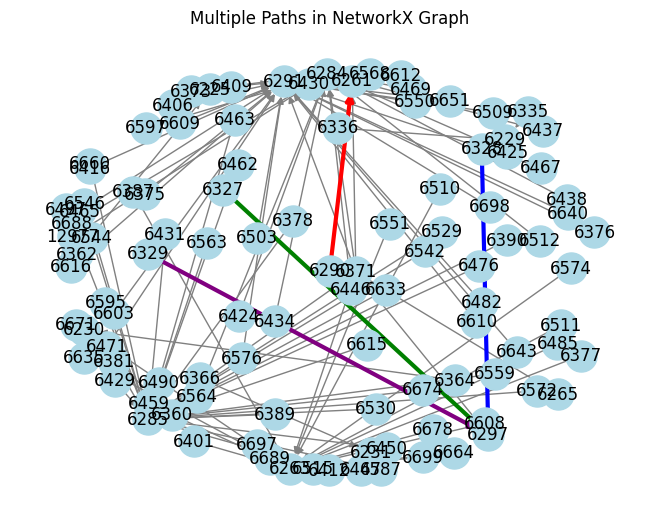

In [793]:
import networkx as nx
import matplotlib.pyplot as plt


# Example: multiple paths as lists of nodes
#paths = df_min_weight_paths['path']
paths = df_min_weight_paths_filtered['path']
# Create an empty graph
G = nx.DiGraph()

# Add edges from all paths
for path in paths:
# Add edges for consecutive pairs of nodes in the path
    edges_G = list(zip(path[:-1], path[1:]))
    G.add_edges_from(edges_G)

# Draw the graph
pos = nx.spring_layout(G, scale=3,k=0.85, iterations=50) # Layout algorithm for positions
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)

# Optionally highlight each path in a different colour
colors = ['red', 'green', 'blue', 'purple']
for path, color in zip(paths, colors):
    edges_zip = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=edges_zip, edge_color=color, width=3)
#plt.figure(figsize=(12, 8))
plt.title("Multiple Paths in NetworkX Graph")
plt.show()

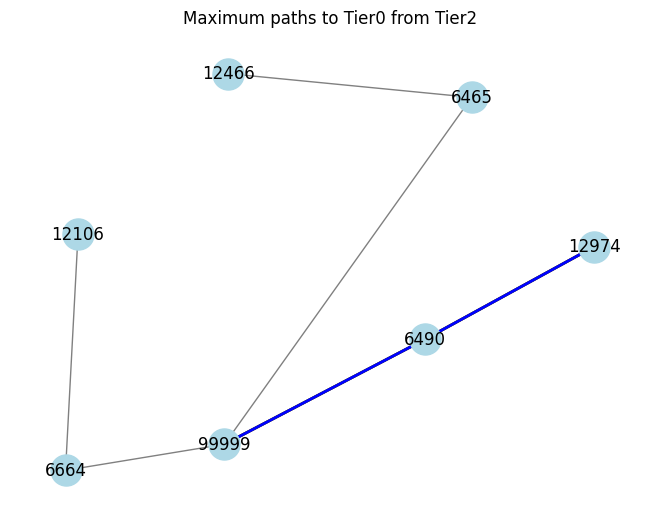

In [794]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.readwrite import json_graph
#import simplejson as json

# Example: multiple paths as lists of nodes
paths = df_max_weight_paths_filtered['path']

# Create an empty graph
G = nx.Graph()

# Add edges from all paths
for path in paths:
# Add edges for consecutive pairs of nodes in the path
    max_edges = list(zip(path[:-1], path[1:]))
    G.add_edges_from(max_edges)

# Draw the graph
#pos = nx.spring_layout(G) # Layout algorithm for positions
pos = nx.spring_layout(G, scale=0.3, k=0.95, iterations=5)#, k=0.15, iterations=2)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)

# Optionally highlight each path in a different colour
colors = ['red', 'green', 'blue']
for path, color in zip(paths, colors):
    edges_list = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=max_edges, edge_color=color, width=2)
#plt.figure(figsize=(12, 8))
plt.title("Maximum paths to Tier0 from Tier2")
plt.show()

#fname = "test.json"
# def save(G, fname):
#     json.dump(dict(nodes=[[n, G.node[n]] for n in G.nodes()],
#                    edges=[[u, v, G.edge[u][v]] for u,v in G.edges()]),
#               open(fname, 'w'), indent=2)

# save(G, "test.json")




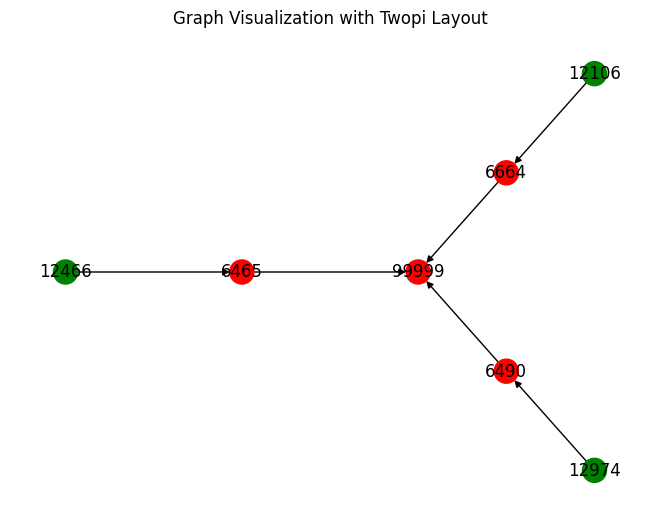

In [795]:
import networkx as nx
import pydot
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import *
# graphviz is installed already, but need lib too
#!apt install libgraphviz-dev
#!pip install pygraphviz
# import pygraphviz as G_pgv

df=df_max_weight_paths_filtered
G = nx.DiGraph()
#graph [root=new_node_id label=twopi]

for index, row in df.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    # Add nodes for all nodes in the path
    for node in path:
        G.add_node(str(node))

    # Add edges for consecutive nodes in the path
    for i in range(len(path) - 1):
        G.add_edge(str(path[i]), str(path[i+1]))
colors = []
#Assuming node 4 is the one to highlight
for node in G.nodes():
    if int(node) in tier0_node_ids:
    #== new_node_id : # Ensure comparison is with string if nodes are strings
        colors.append('red')
    else:
        colors.append('green')

# Set graph attributes to control spacing
G.graph['ranksep'] = '2.0' # Increase separation between ranks
G.graph['nodesep'] = '2.0' # Increase separation between nodes

#G_pgv.graph_attr.update(root=new_node_id,ranksep='3.0',nodesep='2.0')
#G_pgv.draw('pytry.jpg',prog='twopi') # This line caused the error

# Use pydot_layout with 'twopi' program
pos = pydot_layout(G, prog="twopi", root=str(new_node_id)) # Removed root as it might not exist in the graph
nx.draw(G, pos, node_color=colors, with_labels=True)
plt.title("Graph Visualization with Twopi Layout")
plt.savefig("graph_visualization.pdf", format="pdf")
plt.show()
#table(igraph::degree(my_graph, mode = "all"))

In [799]:
from pickle import STOP
#!pip install pyvis

import pandas as pd
from pyvis.network import Network
#pyvis.__version__

#Loading the data
#data = pd.read_csv("facebook_combined.txt", sep=" ", header=None)
df=df_max_weight_paths_filtered
#df.columns = ["source", "target", "path", "weight"]
#sample = df.sample(500, random_state = 1)
#sample.head(10)

net = Network(notebook = True, cdn_resources = "remote",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
)

for index, row in df.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight'] # Changed 'total_weight' to 'weight'

    # Add nodes for all nodes in the path
    for node in path:
      if node in tier0_node_ids:
        net.add_node(str(node), label=str(node), color='red') # Added label for better visualization
      else:
        net.add_node(str(node), label=str(node), color='green')

    # Add edges for consecutive pairs of nodes in the path
    for i in range(len(path) - 1):
        net.add_edge(str(path[i]), str(path[i+1]), weight=weight, title=f"Weight: {weight}") # Added weight and title to edge



net.show("graph.html")

graph.html


In [ ]:
#print(df_max_weight_paths_filtered)
#[df_max_weight_paths_filtered['source'] == 7144]


In [796]:
print(nodes[nodes['id'] == 6490])
print(nodes[nodes['id'] == 6664])
print(nodes[nodes['id'] == 6465])
# print(nodes[nodes['id'] == 303])
#print(nodes[nodes['id'] == 331])
#print(nodes[nodes['id'] == 208])

       id  \
269  6490   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         properties  \
269  {'domain': 'TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1130', 'displayname': 'Marcelene Kanemoto', 'name': 'MKANEMOTO00120@TESTLAB.LOCALE', 'enabled': True, 'pwdlastset': 1717406459, 'lastlogon': -1, 'lastlogontimestamp': -1, 'highvalue': True, 'dontreqpreauth': False, 'hasspn'

In [797]:
#print(edges[edges['id'] == 208])
#tier0_node_ids

In [474]:
edges.head()


,id,type,start,end,label,weight
0,0,relationship,0,1,Contains,2
1,1,relationship,0,2,Contains,2
2,2,relationship,0,3,Contains,2
3,3,relationship,1,4,Contains,2
4,4,relationship,1,5,Contains,2


In [798]:
from graphviz import Digraph
df=df_max_weight_paths_filtered
dot = Digraph()
  # "default"
  # "1in" [height=1]
  # "5in" [])

for index, row in df.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    # Add nodes for all nodes in the path
    for node in path:
        if node in tier0_node_ids:
            dot.node(str(node), str(node), color='red')
        else:
            dot.node(str(node), str(node), color='green')

    # Add edges for consecutive nodes in the path
    for i in range(len(path) - 1):
 #       if path[i+1] is tier0_node_ids:
 #           dot.node(str(path[i]), str(path[i+1]), xlabel="Tier 0")
 #       else:
 #           dot.node(str(path[i]), str(path[i+1]))

#        source == 448; target == 9999;
         dot.edge(str(path[i]),str(path[i+1]))#,label=str(lbl))



print(dot.source)
nodesep=1.5
ranksep = 4
dot.render(view=True)


digraph {
	12106 [label=12106 color=green]
	6664 [label=6664 color=red]
	99999 [label=99999 color=red]
	12106 -> 6664
	6664 -> 99999
	12466 [label=12466 color=green]
	6465 [label=6465 color=red]
	99999 [label=99999 color=red]
	12466 -> 6465
	6465 -> 99999
	12974 [label=12974 color=green]
	6490 [label=6490 color=red]
	99999 [label=99999 color=red]
	12974 -> 6490
	6490 -> 99999
}



'Digraph.gv.pdf'

In [476]:
lbl

,label


In [477]:
# max_graph = json_graph.node_link_data(G)
# #with open('max_graph.json', 'w') as f:
# #  f.write(max_graph)
# max_graph
import simplejson as json
def save(G, fname):
    json.dump(dict(nodes=[[n, G.node[n]] for n in G.nodes()],
                   edges=[[u, v, G.edge[u][v]] for u,v in G.edges()]),
              open(fname, 'w'), indent=4)

nx.write_gml(G, "max_graph.json")
nx.write_gml(G, "max_graph.gml")
nx.write_gexf(G, "max_graph.gexf")

In [478]:
import simplejson as json
import networkx as nx
G = nx.DiGraph()
# add nodes, edges, etc to G ...

def save(G, fname):
    json.dump(dict(nodes=[[n, G.node[n]] for n in G.nodes()],
                   edges=[[u, v, G.edge[u][v]] for u,v in G.edges()]),
              open(fname, 'w'), indent=4)

In [479]:
from collections import Counter

# Create an empty list to store intermediate nodes
middle_nodes = []

# Iterate through each path in the DataFrame
for path in df_max_weight_paths['path']:
    if len(path) >= 3: # Ensure there are enough nodes for a source, middle, and target
        middle_node = path[1] # Get the middle node (index 1)
        middle_nodes.append(middle_node)

# Count occurrences using Counter
node_counts = Counter(middle_nodes)

# Print results in a formatted way
#print("Node      Count:")
#print("-" * 20)
#for node, count in node_counts.most_common(5):
#    print(f"Node {node}: {count} times")

#max_count= pd.DataFrame(node_counts.most_common(5))
max_count = pd.DataFrame(node_counts.most_common(5))
max_count.rename(columns={0: 'id', 1: 'Count'}, inplace=True)
max_count

,id,Count
0,60,1


In [480]:
nodes.keys()

Index(['id', 'properties', 'type', 'l1', 'l2', 'l3', 'weight', 'Tier0',
       'Tier1', 'Tier2'],
      dtype='object')

In [505]:
# Filter nodes to get rows where the id matches those in max_count
matching_nodes = nodes[nodes['id'].isin(max_count['id'])]

# Extract the 'name' from the 'properties' column
names = matching_nodes['properties'].apply(lambda x: x['name'] if isinstance(x, dict) and 'name' in x else None)
names
#filtered_nodes = nodes[nodes['id'].isin(max_count['id'])][['id', 'l1', 'l2', 'l3', 'weight', 'Tier0', 'Tier1', 'Tier2']]

filtered_nodes = matching_nodes[['id', 'l1', 'l2', 'l3', 'weight', 'Tier0', 'Tier1', 'Tier2']]
filtered_nodes#.append(names)



,id,l1,l2,l3,weight,Tier0,Tier1,Tier2
60,60,Base,Group,None,20,1,0,0


In [482]:
nodes.keys()

Index(['id', 'properties', 'type', 'l1', 'l2', 'l3', 'weight', 'Tier0',
       'Tier1', 'Tier2'],
      dtype='object')

In [483]:
nodes[nodes['id'] == 7237]
print(nodes[nodes['id'] == 7301])
print(nodes[nodes['id'] == 7381])
print(nodes[nodes['id'] == 7801])
print(nodes[nodes['id'] == 8154])

Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []


In [ ]:
print(nodes[nodes['id'] == 405])

In [ ]:
/1


In [ ]:
df_shortest_paths_with_weight

In [485]:
# prompt: for each source find minimum weight and target. if weight is the same print out all instances

import pandas as pd
# Group by source and find the minimum weight
min_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].min().reset_index()

# Merge with the original DataFrame to get rows with the minimum weight
result_min = pd.merge(df_shortest_paths_with_weight, min_weights, on=['source', 'total_weight'])

# Print the results
# for index, row in result.iterrows():
#   print(f"Source: {row['source']}, Target: {row['target']}, Minimum Weight: {row['total_weight']}, Path: {row['path']}")


In [487]:
# prompt: for each source find MAXIMUM weight and target. only save the max results in result_max

import pandas as pd
# Group by source and find the maximum weight
max_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].max().reset_index()

# Merge with the original DataFrame to get rows with the maximum weight
result_max = pd.merge(df_shortest_paths_with_weight, max_weights, on=['source', 'total_weight'])

# Print the results
# for index, row in result_max.iterrows():
#   print(f"Source: {row['source']}, Target: {row['target']}, Maximum Weight: {row['total_weight']}, Path: {row['path']}")

In [490]:
# prompt: for each source find minimum weight and target. if weight is the same print out all instances

import pandas as pd
# Group by source and find the minimum weight
min_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].min().reset_index()

# Merge with the original DataFrame to get rows with the minimum weight
result_min = pd.merge(df_shortest_paths_with_weight, min_weights, on=['source', 'total_weight'])

# Print the results
# for index, row in result.iterrows():
#   print(f"Source: {row['source']}, Target: {row['target']}, Max Weight: {row['total_weight']}, Path: {row['path']}")
# df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)
# df_shortest_paths_with_weight

In [493]:
# prompt: for each source IN df_shortest_paths_with_weight find maximum weight and target AND PATH. if weight is the same print out all instances

# Iterate through each unique source node
for source_node in df_shortest_paths_with_weight['source'].unique():
    # Filter the DataFrame for the current source node
    source_df = df_shortest_paths_with_weight[df_shortest_paths_with_weight['source'] == source_node].copy()

    # Find the maximum weight for this source
    max_weight_for_source = source_df['total_weight'].max()

    # Filter for rows with the maximum weight for this source
    max_weight_paths = source_df[source_df['total_weight'] == max_weight_for_source]

    # Print the results for the current source
    print(f"\nSource: {source_node}")
    print(f"Maximum Weight for this source: {max_weight_for_source}")
    print("Paths with maximum weight:")
    for index, row in max_weight_paths.iterrows():
        print(f"  Target: {row['target']}, Path: {row['path']}")


Source: 15
Maximum Weight for this source: 102
Paths with maximum weight:
  Target: 9999, Path: [15, 301, 9999]

Source: 26
Maximum Weight for this source: 102
Paths with maximum weight:
  Target: 9999, Path: [26, 331, 9999]

Source: 27
Maximum Weight for this source: 102
Paths with maximum weight:
  Target: 9999, Path: [27, 392, 9999]

Source: 29
Maximum Weight for this source: 102
Paths with maximum weight:
  Target: 9999, Path: [29, 481, 9999]

Source: 301
Maximum Weight for this source: 100
Paths with maximum weight:
  Target: 9999, Path: [301, 9999]

Source: 318
Maximum Weight for this source: 100
Paths with maximum weight:
  Target: 9999, Path: [318, 9999]

Source: 331
Maximum Weight for this source: 100
Paths with maximum weight:
  Target: 9999, Path: [331, 9999]

Source: 341
Maximum Weight for this source: 100
Paths with maximum weight:
  Target: 9999, Path: [341, 9999]

Source: 357
Maximum Weight for this source: 100
Paths with maximum weight:
  Target: 9999, Path: [357, 9999

In [ ]:
shortest_paths_with_weight

In [ ]:
result_min

In [ ]:
result_max

In [ ]:
# prompt: show me where source appears the most within the results_max dataframe. is ther one source that appears most

source_counts = result_max['source'].value_counts()

print("Count of each source in result_max:")
print(source_counts)

most_frequent_source = source_counts.index[0]
most_frequent_count = source_counts.iloc[0]

print(f"\nThe source that appears most frequently is: {most_frequent_source} with a count of {most_frequent_count}")

if most_frequent_count > 1:
  print("Yes, there is one source that appears most.")
else:
  print("No single source appears most frequently (or all sources appear only once).")

In [ ]:
source_counts_min = result_min['source'].value_counts()

print("Count of each source in result_max:")
print(source_counts_min)

most_frequent_source_min = source_counts.index[0]
most_frequent_count_min = source_counts.iloc[0]

print(f"\nThe source that appears most frequently is: {most_frequent_source} with a count of {most_frequent_count}")

if most_frequent_count_min > 1:
  print("Yes, there is one source that appears most.")
else:
  print("No single source appears most frequently (or all sources appear only once).")

In [ ]:
# prompt: convert result into a DataFrame

import pandas as pd
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)
df_shortest_paths_with_weight

In [ ]:
print(edges[edges['end'] == 301])

In [ ]:
shortest_paths_with_weight

In [ ]:
# prompt: for each node in shortest_paths_with_weight, find the minimum total_weight and the maxium total_weight, save it to a DataFrame

import pandas as pd
# Initialize a dictionary to store min and max weights for each target node
target_node_weights = {}

# Iterate through the shortest paths
for path_info in shortest_paths_with_weight:
    target_node = path_info['target']
    total_weight = path_info['total_weight']

    if target_node not in target_node_weights:
        target_node_weights[target_node] = {'min_weight': float('inf'), 'max_weight': float('-inf')}

    # Update min and max weights
    target_node_weights[target_node]['min_weight'] = min(target_node_weights[target_node]['min_weight'], total_weight)
    target_node_weights[target_node]['max_weight'] = max(target_node_weights[target_node]['max_weight'], total_weight)

# Convert the dictionary to a DataFrame
min_max_weights_df = pd.DataFrame.from_dict(target_node_weights, orient='index')
min_max_weights_df.index.name = 'target_node'
min_max_weights_df = min_max_weights_df.reset_index()

# Display the resulting DataFrame
print("\nMin and Max Total Weights for Each Target Node:")
min_max_weights_df

In [500]:
# prompt: for each record in "for each record in "shortest_paths_filtered" add up the weights and find the smallest and largest combined weights and the path

# Find the path with the smallest total weight
min_weight_path_info = min(shortest_paths_with_weight, key=lambda item: item['total_weight'])

# Find the path with the largest total weight
max_weight_path_info = max(shortest_paths_with_weight, key=lambda item: item['total_weight'])

print("\nPath with the Smallest Combined Weight:")
print(f"Source: {min_weight_path_info['source']}, Target: {min_weight_path_info['target']}, Total Weight: {min_weight_path_info['total_weight']}, Path: {min_weight_path_info['path']}")

print("\nPath with the Largest Combined Weight:")
print(f"Source: {max_weight_path_info['source']}, Target: {max_weight_path_info['target']}, Total Weight: {max_weight_path_info['total_weight']}, Path: {max_weight_path_info['path']}")


Path with the Smallest Combined Weight:
Source: 700, Target: 66, Total Weight: 1, Path: [700, 66]

Path with the Largest Combined Weight:
Source: 705, Target: 9999, Total Weight: 110, Path: [705, 60, 8, 9999]


In [ ]:
# prompt: for each record in "shortest_paths_filtered" add up the weights and find the smallest and largest combined weights and the path for the largest weight

# Function to calculate the total weight of a path
# def calculate_path_weight(graph, path):
#     total_weight = 0
#     for i in range(len(path) - 1):
#         # Add node weight
#         total_weight += graph.nodes[path[i]].get('weight', 0)
#         # Add edge weight
#         total_weight += graph[path[i]][path[i+1]].get('weight', 0)
#     # Add the weight of the last node in the path
#     if path:
#         total_weight += graph.nodes[path[-1]].get('weight', 0)
#     return total_weight

# all_path_weights = {}

# # Iterate through each source and its paths in shortest_paths_filtered
# for source, paths_from_source in shortest_paths_list.items():
#     all_path_weights[source] = {}
#     # Iterate through each target and its path
#     for target, path in paths_from_source.items():
#         # Calculate the weight of the path using the original graph G
#         weight = calculate_path_weight(G, path)
#         all_path_weights[source][target] = weight

# # Find the smallest and largest combined weights
# min_weight = float('inf')
# max_weight = float('-inf')
# largest_weight_path = None
# largest_weight_source = None
# largest_weight_target = None

# for source, paths_from_source in all_path_weights.items():
#     for target, weight in paths_from_source.items():
#         if weight < min_weight:
#             min_weight_source = source
#             min_weight_target = target
#             min_weight_path = shortest_paths_filtered[source][target]
#             min_weight = weight
#         if weight > max_weight:
#             max_weight = weight
#             largest_weight_source = source
#             largest_weight_target = target
#             largest_weight_path = shortest_paths_filtered[source][target]

# print(f"Smallest combined weight: {min_weight}")
# print(f"Path for the smallest weight: {min_weight_path}")
# print(f"Source for the smallest weight path: {min_weight_source}")
# print(f"Target for the smallest weight path: {min_weight_target}")
# print(f"Largest combined weight: {max_weight}")
# print(f"Path for the largest weight: {largest_weight_path}")
# print(f"Source for the largest weight path: {largest_weight_source}")
# print(f"Target for the largest weight path: {largest_weight_target}")

In [ ]:

print(nodes[nodes['id'] == 111])
print(nodes[nodes['id'] == 8])
print(nodes[nodes['id'] == 26])
#print(nodes[nodes['id'] == 444])
#print(nodes[nodes['id'] == 331])
#print(nodes[nodes['id'] == 208])

In [496]:
len(selected_nodes)

949

In [ ]:
selected_nodes

In [ ]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
shortest_paths

In [ ]:
shortest_paths_filtered

In [805]:
# prompt: can you display the combined weight from the shortest_paths and display the path with the max weight

# Function to calculate the total weight of a path
def calculate_path_weight(graph, path):
    total_weight = 0
    # Add the weight of the starting node
    if path:
        total_weight += graph.nodes[path[0]].get('weight', 0) # Get node weight
    # Add the weight of the edges and the weights of subsequent nodes
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        # Add edge weight
        total_weight += graph.edges[u, v].get('weight', 0) # Get edge weight
        # Add weight of the next node
        total_weight += graph.nodes[v].get('weight', 0) # Get node weight
    return total_weight

max_weight = -1
max_path = None

# Iterate through the filtered shortest paths and calculate total weights
for source, paths in shortest_paths_filtered.items():
    for target, path in paths.items():
        current_weight = calculate_path_weight(G, path)
#        print(f"Path from {source} to {target}: {path}, Combined Weight: {current_weight}")
        if current_weight > max_weight:
            max_weight = current_weight
            max_path = path

print(f"\nPath with the maximum combined weight: {max_path}")
print(f"Maximum combined weight: {max_weight}")

KeyError: 6222

In [502]:
max_path
max_path = pd.DataFrame(max_path)
max_path.head()


""


In [ ]:
rename = {0: 'id'}
max_path = max_path.rename(columns=rename)
max_path

In [ ]:
# prompt: get label from nodes where id=max_path['id']

# Assuming max_path is a DataFrame with an 'id' column representing the node IDs in the max path
# and nodes is a DataFrame with 'id' and 'properties' columns.

# Get the list of node IDs from the max_path DataFrame
max_path_node_ids = max_path['id'].tolist()

# Filter the nodes DataFrame to get only the nodes that are in the max_path
nodes_in_max_path = nodes[nodes['id'].isin(max_path_node_ids)].copy()

# Now, extract the 'name' property from the 'properties' column for these nodes
# Use .loc to avoid SettingWithCopyWarning
# We use a lambda function with .apply to safely access nested dictionary keys.
max_path_node_labels = nodes_in_max_path.loc[:, 'properties'].apply(lambda x: x.get('name', ''))

print("Labels of nodes in the max path:")
print(max_path_node_labels.tolist())


In [ ]:
max_path

ignore from here


In [ ]:
vertices = nodes['id'].tolist()
vertices


In [ ]:
adj_list=adj.values.tolist()
len(adj_list)

In [503]:
import networkx as nx
import matplotlib.pyplot as plt

def createAdjacencyMatrix(vertices,edges):
  noofvertices=len(vertices)
  adjM=[]
  while(len(adjM)<noofvertices):
    temp=[]
    for i in range(noofvertices):
      temp.append(0)
    adjM.append(temp)
  for edge in edges:
    i=edge[0]
    j=edge[1]
    if i>=noofvertices or j>=noofvertices or i<0 or j<0:
      print(f"Not a Proper Input in Edge {i},{j}")
    else:
      adjM[i][j]=1
      adjM[j][i]=1
#  G=nx.Graph()
#  G.add_edges_from(edges)
#  nx.draw_networkx(G)
#  plt.show()
  return adjM
vertices = vertices
edges = adj_list
adjM=createAdjacencyMatrix(vertices,edges)


NameError: name 'vertices' is not defined

In [ ]:
#adjM.shape
import numpy as np
len(adjM)
arr = np.array(adjM)

newarr = arr.reshape(10075, 10075)

print(newarr)

In [ ]:
def create_adjacency_matrix(V, edges):
    # Initialize an empty V x V matrix with all zeros
    matrix = [[0] * V for _ in range(V)]

    # Populate the matrix based on the edges
    for edge in edges:
        u, v = edge
        matrix[u][v] = 1
#       matrix[v][u] = 1  # Undirected graph

    return matrix
V1 = len(adj)
edges1 = adj[['start', 'end']].values.tolist()
adj_matrix1 = create_adjacency_matrix(V1, edges1)
for row in adj_matrix1:
    print(row)
print()

In [ ]:
type(adj)

In [ ]:
import pandas as pd

# Initialize an empty DataFrame to store selected records
selected_records = pd.DataFrame(columns=filtered_nodes_regex.columns)

# Iterate through each row of the filtered_nodes_regex DataFrame
for index, row in filtered_nodes_regex.iterrows():
    properties = row['properties']

    # Check if 'properties' is a dictionary and contains 'highvalue' and if 'highvalue' is True
    if isinstance(properties, dict) and 'highvalue' in properties and properties['highvalue'] == True:
        # Append the entire row to the selected_records DataFrame
        selected_records = pd.concat([selected_records, pd.DataFrame([row])], ignore_index=True)

# Display the selected_records DataFrame
print("Selected records where 'highvalue' is True:")
display(selected_records)

In [ ]:
# Create a new node ID based on the length of lastnode
new_node_id = int('9' * lastnode)

print(f"The new node ID is: {new_node_id}")

In [ ]:
!pip install pyvis

In [ ]:
import pandas as pd
from pyvis.network import Network

df=df_max_weight_paths

net = Network(notebook = True, cdn_resources = "remote",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
)

for index, row in df.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    # Add nodes for all nodes in the path
    for node in path:
        # Assuming tier0_node_ids is a list or set of Tier 0 node IDs
        if node in tier0_node_ids:
            net.add_node(str(node), label=str(node), color='red')
        else:
            net.add_node(str(node), label=str(node))

    # Add edges for consecutive pairs of nodes in the path
    for i in range(len(path) - 1):
        net.add_edge(str(path[i]), str(path[i+1]), weight=weight, title=f"Weight: {weight}")

net.show("graph.html")